In [ ]:
# ============================================
# Stage 0: Setup
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import auth
auth.authenticate_user()

print("Authenticated with Google.")

Authenticated with Google.


### Data Source Note

The preferred modeling file is `structured/datasets/listings_llm.csv`, but that file is stored in Mark's private Google Cloud Storage bucket and my account does not currently have read access. For this first modeling pass, I am using the latest `preds.csv` artifact from the GitHub `results` folder because it still contains structured listing fields and actual prices. Once Mark shares the original `listings_llm.csv` file, this loading cell should be replaced with the cleaner source file.

In [ ]:
# ============================================
# Stage 0: Clone Mark's GitHub Repo
# ============================================

import os
import shutil
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO_URL = "https://github.com/OPIM5512-mdk23002/myscrapers-mdk23002.git"
REPO_DIR = "myscrapers-mdk23002"

if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)

!git clone $REPO_URL

RESULTS_DIR = os.path.join(REPO_DIR, "results")

pred_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*-preds.csv")))

print("Prediction files found:", len(pred_files))
print("Latest prediction file:", pred_files[-1])

Cloning into 'myscrapers-mdk23002'...
remote: Enumerating objects: 4267, done.
remote: Counting objects: 100% (244/244), done.
remote: Compressing objects: 100% (238/238), done.
remote: Total 4267 (delta 154), reused 76 (delta 6), pack-reused 4023 (from 3)
Receiving objects: 100% (4267/4267), 51.12 MiB | 44.18 MiB/s, done.
Resolving deltas: 100% (2548/2548), done.
Prediction files found: 476
Latest prediction file: myscrapers-mdk23002/results/2026050621-preds.csv


In [ ]:
# ============================================
# Stage 0: Load Latest Prediction Artifact
# ============================================

df = pd.read_csv(pred_files[-1])

print("Dataset shape:", df.shape)
display(df.head())
print(df.columns.tolist())

Dataset shape: (294, 18)


,post_id,scraped_at,make,model,year,mileage,price,transmission,drivetrain,fuel_type,engine_cylinders,condition,color,body_type,title_status,image_url,actual_price,pred_price
0,7929151326,2026-05-06T04:00:37Z,Subaru,Crosstrek,2018,173000,8900.0,automatic,4wd,gasoline,4.0,like new,red,wagon,clean,https://images.craigslist.org/00q0q_kL52xbCrmm...,8900.0,7850.50
1,7931049500,2026-05-06T04:00:37Z,Honda,CR-V,2010,146000,7900.0,automatic,awd,gasoline,4.0,good,NaN,suv,clean,https://images.craigslist.org/00M0M_5kaBZxl65K...,7900.0,6740.59
2,7931482785,2026-05-06T04:00:37Z,Land Rover,Range Rover Sport,2017,95262,16900.0,automatic,NaN,gasoline,6.0,NaN,black,suv,clean,https://images.craigslist.org/00L0L_9rMYBhbnMy...,16900.0,16879.23
3,7931381712,2026-05-06T05:00:06Z,Honda,Civic,2013,112885,8999.0,automatic,fwd,gasoline,4.0,like new,blue,sedan,clean,https://images.craigslist.org/00707_cGZqaRDaMV...,8999.0,4436.46
4,7931515827,2026-05-06T05:00:06Z,Ford,F-150,2005,169000,11800.0,automatic,4wd,gasoline,8.0,good,red,truck,clean,https://images.craigslist.org/00O0O_83vc5nbtoL...,11800.0,5503.88


['post_id', 'scraped_at', 'make', 'model', 'year', 'mileage', 'price', 'transmission', 'drivetrain', 'fuel_type', 'engine_cylinders', 'condition', 'color', 'body_type', 'title_status', 'image_url', 'actual_price', 'pred_price']


# Stage 1: Create Price Tier Target

In [ ]:
df_model = df.copy()

# Use cleaned actual_price if available, otherwise clean price manually
if "actual_price" in df_model.columns:
    df_model["price_num"] = pd.to_numeric(df_model["actual_price"], errors="coerce")
else:
    df_model["price_num"] = (
        df_model["price"]
        .astype(str)
        .str.replace(r"[^\d.]+", "", regex=True)
        .str.strip()
    )
    df_model["price_num"] = pd.to_numeric(df_model["price_num"], errors="coerce")

# Drop rows without usable target
df_model = df_model.dropna(subset=["price_num"])

# Remove obvious invalid/extreme prices
df_model = df_model[df_model["price_num"] > 500]
df_model = df_model[df_model["price_num"] < 100000]

# Create three balanced price tiers
df_model["price_tier"] = pd.qcut(
    df_model["price_num"],
    q=3,
    labels=["low", "medium", "high"]
)

print("Shape after target cleaning:", df_model.shape)

tier_counts = df_model["price_tier"].value_counts().sort_index()
display(tier_counts)

Shape after target cleaning: (284, 20)


,count
price_tier,
low,95
medium,96
high,93


# Stage 2: Create Clean Structured Modeling Dataset

In [ ]:
# ============================================
# Stage 2: Create Clean Structured Modeling Dataset
# ============================================

def clean_numeric(series):
    return (
        series
        .astype(str)
        .str.replace(r"[^\d.]+", "", regex=True)
        .str.strip()
        .replace("", np.nan)
        .pipe(pd.to_numeric, errors="coerce")
    )

# Clean numeric columns
df_model["year_num"] = clean_numeric(df_model["year"])
df_model["mileage_num"] = clean_numeric(df_model["mileage"])

if "engine_cylinders" in df_model.columns:
    df_model["engine_cylinders_num"] = clean_numeric(df_model["engine_cylinders"])

# Engineer simple vehicle features
df_model["vehicle_age"] = 2026 - df_model["year_num"]
df_model["miles_per_year"] = df_model["mileage_num"] / df_model["vehicle_age"].replace(0, np.nan)

# Structured features from Mark's existing pipeline
candidate_features = [
    "year_num",
    "mileage_num",
    "vehicle_age",
    "miles_per_year",
    "engine_cylinders_num",
    "make",
    "model",
    "transmission",
    "drivetrain",
    "fuel_type",
    "condition",
    "color",
    "body_type",
    "title_status"
]

structured_features = [col for col in candidate_features if col in df_model.columns]

keep_cols = ["post_id", "scraped_at", "price_num", "price_tier"] + structured_features
keep_cols = [col for col in keep_cols if col in df_model.columns]

df_structured = df_model[keep_cols].copy()

print("Structured modeling dataframe shape:", df_structured.shape)
print("\nStructured features:")
print(structured_features)

display(df_structured.head())

Structured modeling dataframe shape: (284, 18)

Structured features:
['year_num', 'mileage_num', 'vehicle_age', 'miles_per_year', 'engine_cylinders_num', 'make', 'model', 'transmission', 'drivetrain', 'fuel_type', 'condition', 'color', 'body_type', 'title_status']


,post_id,scraped_at,price_num,price_tier,year_num,mileage_num,vehicle_age,miles_per_year,engine_cylinders_num,make,model,transmission,drivetrain,fuel_type,condition,color,body_type,title_status
0,7929151326,2026-05-06T04:00:37Z,8900.0,medium,2018,173000,8,21625.000000,4.0,Subaru,Crosstrek,automatic,4wd,gasoline,like new,red,wagon,clean
1,7931049500,2026-05-06T04:00:37Z,7900.0,medium,2010,146000,16,9125.000000,4.0,Honda,CR-V,automatic,awd,gasoline,good,NaN,suv,clean
2,7931482785,2026-05-06T04:00:37Z,16900.0,high,2017,95262,9,10584.666667,6.0,Land Rover,Range Rover Sport,automatic,NaN,gasoline,NaN,black,suv,clean
3,7931381712,2026-05-06T05:00:06Z,8999.0,medium,2013,112885,13,8683.461538,4.0,Honda,Civic,automatic,fwd,gasoline,like new,blue,sedan,clean
4,7931515827,2026-05-06T05:00:06Z,11800.0,high,2005,169000,21,8047.619048,8.0,Ford,F-150,automatic,4wd,gasoline,good,red,truck,clean


In [ ]:
# ============================================
# Stage 2: Missing Value Summary
# ============================================

missing_summary = df_structured.isna().sum().sort_values(ascending=False)

display(missing_summary)

print("Rows:", df_structured.shape[0])
print("Columns:", df_structured.shape[1])

,0
condition,59
drivetrain,51
color,46
engine_cylinders_num,38
body_type,26
miles_per_year,3
fuel_type,2
transmission,1
scraped_at,0
post_id,0


Rows: 284
Columns: 18


# Stage 3: Split Data Once

In [ ]:
# ============================================
# Stage 3: Split Data Once
# ============================================

from sklearn.model_selection import train_test_split

X = df_structured[structured_features].copy()
y = df_structured["price_tier"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain class counts:")
display(y_train.value_counts().sort_index())

print("\nTest class counts:")
display(y_test.value_counts().sort_index())

print("\nTrain class distribution:")
display(y_train.value_counts(normalize=True).sort_index())

print("\nTest class distribution:")
display(y_test.value_counts(normalize=True).sort_index())

X_train shape: (227, 14)
X_test shape: (57, 14)

Train class counts:


,count
price_tier,
low,76
medium,77
high,74



Test class counts:


,count
price_tier,
low,19
medium,19
high,19



Train class distribution:


,proportion
price_tier,
low,0.334802
medium,0.339207
high,0.325991



Test class distribution:


,proportion
price_tier,
low,0.333333
medium,0.333333
high,0.333333


In [ ]:
# ============================================
# Stage 3: Sanity Check for Feature Leakage
# ============================================

leakage_cols = [col for col in X.columns if "price" in col.lower()]

print("Columns with 'price' in the feature set:")
print(leakage_cols)

Columns with 'price' in the feature set:
[]


# Stage 4: Structured Baseline Preprocessing
### Structured Baseline Model

This first model uses only structured listing fields, such as year, mileage, make, model, fuel type, condition, and LLM-extracted vehicle attributes. I am intentionally leaving out listing text and images here so this model can act as the baseline. If later text or image models perform better, we can more clearly say those unstructured inputs added useful signal.

In [ ]:
# ============================================
# Stage 4: Structured Baseline Preprocessing
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)
print("Class labels:", label_encoder.classes_)

Numeric features: ['year_num', 'mileage_num', 'vehicle_age', 'miles_per_year', 'engine_cylinders_num']
Categorical features: ['make', 'model', 'transmission', 'drivetrain', 'fuel_type', 'condition', 'color', 'body_type', 'title_status']
Processed X_train shape: (227, 223)
Processed X_test shape: (57, 223)
Class labels: ['high' 'low' 'medium']


In [ ]:
# ============================================
# Stage 4: Build Dense Neural Network Baseline
# ============================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

num_classes = len(label_encoder.classes_)
input_dim = X_train_processed.shape[1]

model_structured = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

model_structured.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_structured.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,515 (64.51 KB)

 Trainable params: 16,515 (64.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# Stage 4: Train Structured Baseline
# ============================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_structured = model_structured.fit(
    X_train_processed,
    y_train_encoded,
    validation_split=0.20,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3702 - loss: 1.0944 - val_accuracy: 0.5435 - val_loss: 1.0506
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4972 - loss: 1.0368 - val_accuracy: 0.5652 - val_loss: 1.0207
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5801 - loss: 0.9747 - val_accuracy: 0.5870 - val_loss: 0.9814
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6188 - loss: 0.9173 - val_accuracy: 0.5870 - val_loss: 0.9341
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6851 - loss: 0.8455 - val_accuracy: 0.5870 - val_loss: 0.8914
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7182 - loss: 0.7997 - val_accuracy: 0.6304 - val_loss: 0.8481
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7459 - loss: 0.7187 - val_accuracy: 0.6304 - val_loss: 0.8154
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7901 - loss: 0.6442 - val_accuracy: 0.6304 - val_loss

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


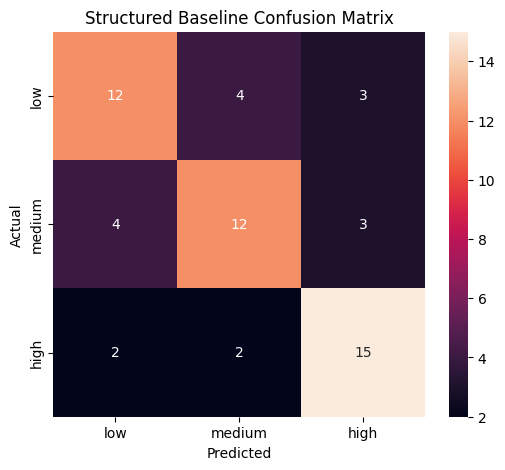

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

ordered_labels = ["low", "medium", "high"]

# Make predictions on the processed test data
y_pred_probabilities = model_structured.predict(X_test_processed)
y_pred_encoded = np.argmax(y_pred_probabilities, axis=1)

# Convert encoded predictions back to labels
y_test_labels = label_encoder.inverse_transform(y_test_encoded)
y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)

cm_ordered = confusion_matrix(
    y_test_labels,
    y_pred_labels,
    labels=ordered_labels
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_ordered,
    annot=True,
    fmt="d",
    xticklabels=ordered_labels,
    yticklabels=ordered_labels
)
plt.title("Structured Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ============================================
# Save Structured Baseline Results
# ============================================

from sklearn.metrics import accuracy_score, f1_score

# Calculate metrics using y_test_encoded and y_pred_encoded
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
weighted_f1 = f1_score(y_test_encoded, y_pred_encoded, average='weighted')

model_results = []

model_results.append({
    "model_name": "Structured Dense Baseline",
    "input_type": "Structured listing fields",
    "accuracy": accuracy,
    "weighted_f1": weighted_f1,
    "main_takeaway": "Strong on low and high tiers, weaker on medium tier."
})

results_df = pd.DataFrame(model_results)
display(results_df)

,model_name,input_type,accuracy,weighted_f1,main_takeaway
0,Structured Dense Baseline,Structured listing fields,0.684211,0.682432,"Strong on low and high tiers, weaker on medium..."


# Stage 7: Prepare the Image Data

This section checks whether Craigslist listing images are available, readable, and correctly matched to each listing. The model uses the first usable image per listing to avoid duplicated image examples from the same vehicle.

In [ ]:
# ============================================
# Stage 7: Setup for Image Data
# ============================================

import os
import glob
import shutil
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from io import BytesIO

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# ============================================
# Stage 7: Create Price Tier Target for Image Model
# ============================================

df_img = df_model.copy() # Initialize df_img from df_model
df_img_model = df_img.copy()

if "actual_price" in df_img_model.columns:
    df_img_model["price_num"] = pd.to_numeric(df_img_model["actual_price"], errors="coerce")
else:
    df_img_model["price_num"] = (
        df_img_model["price"]
        .astype(str)
        .str.replace(r"[^\d.]+", "", regex=True)
        .str.strip()
    )
    df_img_model["price_num"] = pd.to_numeric(df_img_model["price_num"], errors="coerce")

df_img_model = df_img_model.dropna(subset=["price_num"])
df_img_model = df_img_model[df_img_model["price_num"] > 500]
df_img_model = df_img_model[df_img_model["price_num"] < 100000]

df_img_model["price_tier"] = pd.qcut(
    df_img_model["price_num"],
    q=3,
    labels=["low", "medium", "high"]
)

print("Image modeling dataframe shape:", df_img_model.shape)
display(df_img_model["price_tier"].value_counts().sort_index())

Image modeling dataframe shape: (284, 25)


,count
price_tier,
low,95
medium,96
high,93


In [ ]:
# ============================================
# Stage 7: Check for Image URL or Image Path Columns
# ============================================

possible_image_cols = [
    col for col in df_img_model.columns
    if any(term in col.lower() for term in ["image", "img", "photo", "picture", "url"])
]

print("Possible image-related columns:")
print(possible_image_cols)

if len(possible_image_cols) == 0:
    print("No obvious image columns found in this dataset.")
    print("Next step: check GCS storage folders or scraper output JSONL for image URLs.")
else:
    for col in possible_image_cols:
        print("\nColumn:", col)
        display(df_img_model[[col]].dropna().head(10))

Possible image-related columns:
['image_url']

Column: image_url


,image_url
0,https://images.craigslist.org/00q0q_kL52xbCrmm...
1,https://images.craigslist.org/00M0M_5kaBZxl65K...
2,https://images.craigslist.org/00L0L_9rMYBhbnMy...
3,https://images.craigslist.org/00707_cGZqaRDaMV...
4,https://images.craigslist.org/00O0O_83vc5nbtoL...
5,https://images.craigslist.org/00f0f_8VUY2xJ7FF...
6,https://images.craigslist.org/01414_gTv4K6pDGq...
7,https://images.craigslist.org/01212_3fcR5u6Pfm...
8,https://images.craigslist.org/00O0O_kdAtuY55v5...
9,https://images.craigslist.org/01515_2028uO8xxm...


# Stage 7: Prepare the Image Data

This section prepares Craigslist listing images for image-only modeling. Since image URLs are available, I use the first image URL per listing, download the image, resize it to 224x224, and match it to the listing-level price_tier target.

In [ ]:
# ============================================
# Stage 7: Image Data Setup
# ============================================

import requests
from PIL import Image
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import img_to_array

print("Image libraries loaded.")

Image libraries loaded.


In [ ]:
# ============================================
# Stage 7: Confirm Image URL Column
# ============================================

image_cols = [
    col for col in df_img_model.columns
    if any(term in col.lower() for term in ["image", "img", "photo", "picture", "url"])
]

print("Possible image-related columns:")
print(image_cols)

display(df_img_model[image_cols].dropna().head())

Possible image-related columns:
['image_url']


,image_url
0,https://images.craigslist.org/00q0q_kL52xbCrmm...
1,https://images.craigslist.org/00M0M_5kaBZxl65K...
2,https://images.craigslist.org/00L0L_9rMYBhbnMy...
3,https://images.craigslist.org/00707_cGZqaRDaMV...
4,https://images.craigslist.org/00O0O_83vc5nbtoL...


In [ ]:
# ============================================
# Stage 7: Filter to Listings with Image URLs
# ============================================

IMAGE_URL_COL = "image_url"

usable_img_df = df_img_model.dropna(subset=[IMAGE_URL_COL]).copy()

usable_img_df[IMAGE_URL_COL] = usable_img_df[IMAGE_URL_COL].astype(str).str.strip()

usable_img_df = usable_img_df[
    usable_img_df[IMAGE_URL_COL].str.startswith("http")
].copy()

print("Total listings:", len(df_img_model))
print("Listings with usable image URLs:", len(usable_img_df))
print("Listings without usable image URLs:", len(df_img_model) - len(usable_img_df))

display(usable_img_df[["post_id", "price_num", "price_tier", IMAGE_URL_COL]].head())

Total listings: 284
Listings with usable image URLs: 284
Listings without usable image URLs: 0


,post_id,price_num,price_tier,image_url
0,7929151326,8900.0,medium,https://images.craigslist.org/00q0q_kL52xbCrmm...
1,7931049500,7900.0,medium,https://images.craigslist.org/00M0M_5kaBZxl65K...
2,7931482785,16900.0,high,https://images.craigslist.org/00L0L_9rMYBhbnMy...
3,7931381712,8999.0,medium,https://images.craigslist.org/00707_cGZqaRDaMV...
4,7931515827,11800.0,high,https://images.craigslist.org/00O0O_83vc5nbtoL...


In [ ]:
# ============================================
# Stage 7: Download, Read, and Resize Images
# ============================================

IMG_SIZE = 224
MAX_IMAGES = len(usable_img_df)

X_images = []
y_labels = []
valid_post_ids = []
valid_image_urls = []

for idx, row in usable_img_df.head(MAX_IMAGES).iterrows():
    image_url = row[IMAGE_URL_COL]

    try:
        response = requests.get(
            image_url,
            timeout=10,
            headers={"User-Agent": "Mozilla/5.0"}
        )
        response.raise_for_status()

        img = Image.open(BytesIO(response.content)).convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE))
        img_arr = img_to_array(img)

        X_images.append(img_arr)
        y_labels.append(row["price_tier"])
        valid_post_ids.append(row["post_id"])
        valid_image_urls.append(image_url)

    except Exception as e:
        print("Bad image skipped:", image_url, "| Error:", e)

X_images = np.array(X_images, dtype="float32")
y_labels = np.array(y_labels)

print("Image size used:", IMG_SIZE, "x", IMG_SIZE)
print("Final image array shape:", X_images.shape)
print("Final label array shape:", y_labels.shape)
print("Final image dataset size:", len(X_images))

Image size used: 224 x 224
Final image array shape: (284, 224, 224, 3)
Final label array shape: (284,)
Final image dataset size: 284


In [ ]:
# ============================================
# Stage 7: Image Dataset Summary
# ============================================

image_dataset_summary = {
    "total_listings": len(df_img_model),
    "listings_with_image_urls": len(usable_img_df),
    "images_successfully_loaded": len(X_images),
    "image_height": IMG_SIZE,
    "image_width": IMG_SIZE,
    "final_image_dataset_size": len(X_images)
}

image_dataset_summary

{'total_listings': 284,
 'listings_with_image_urls': 284,
 'images_successfully_loaded': 284,
 'image_height': 224,
 'image_width': 224,
 'final_image_dataset_size': 284}

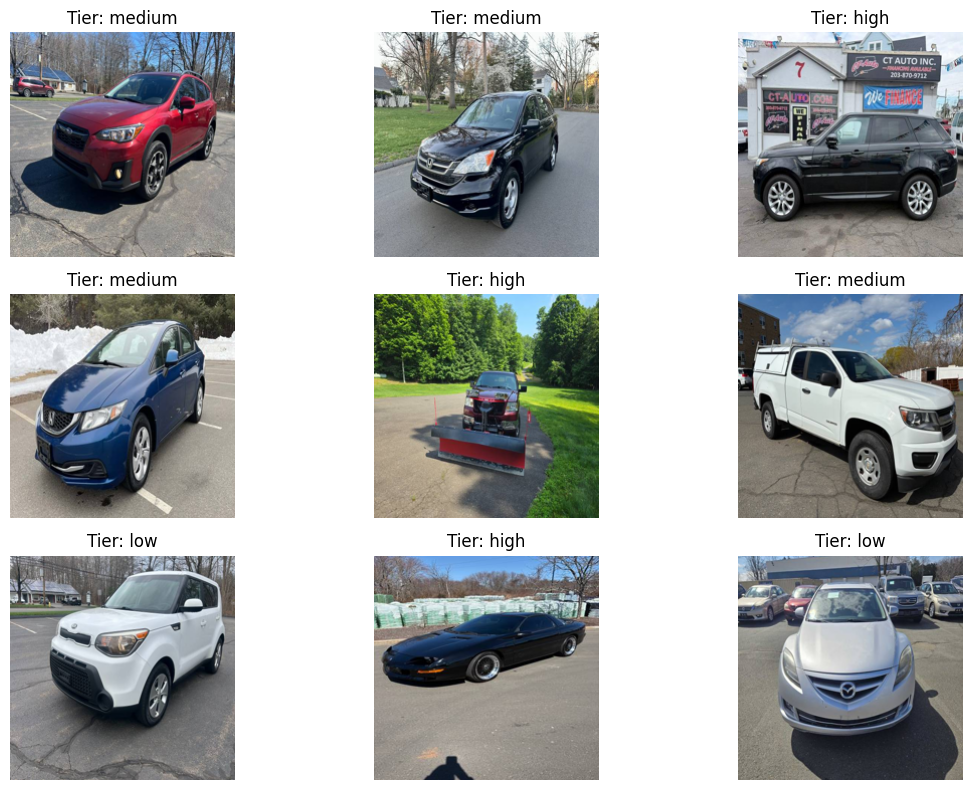

In [ ]:
# ============================================
# Stage 7: Display Example Images
# ============================================

plt.figure(figsize=(12, 8))

sample_n = min(9, len(X_images))

for i in range(sample_n):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_images[i].astype("uint8"))
    plt.title(f"Tier: {y_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Stage 8: Build the Image-Only ConvNet Model

This section trains an image-only model using MobileNetV2 as a pretrained feature extractor. The base model is frozen first, then custom classification layers are added for price tier prediction.

In [ ]:
# ============================================
# Stage 8: Encode Labels and Split Data
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
y_categorical = to_categorical(y_encoded)

print("Class mapping:")
for class_id, class_name in enumerate(label_encoder.classes_):
    print(class_id, "=", class_name)

X_train, X_test, y_train, y_test = train_test_split(
    X_images,
    y_categorical,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

X_train_preprocessed = preprocess_input(X_train.copy())
X_test_preprocessed = preprocess_input(X_test.copy())

print("X_train shape:", X_train_preprocessed.shape)
print("X_test shape:", X_test_preprocessed.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Class mapping:
0 = high
1 = low
2 = medium
X_train shape: (227, 224, 224, 3)
X_test shape: (57, 224, 224, 3)
y_train shape: (227, 3)
y_test shape: (57, 3)


In [ ]:
# ============================================
# Stage 8: Build Image-Only MobileNetV2 Model
# ============================================

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

NUM_CLASSES = y_categorical.shape[1]

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.30)(x)
output_layer = Dense(NUM_CLASSES, activation="softmax")(x)

image_model = Model(inputs=base_model.input, outputs=output_layer)

image_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

image_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ============================================
# Stage 8: Train Image-Only Model
# ============================================

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = image_model.fit(
    X_train_preprocessed,
    y_train,
    validation_split=0.20,
    epochs=25,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 577ms/step - accuracy: 0.4033 - loss: 1.2698 - val_accuracy: 0.5870 - val_loss: 0.8666
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 512ms/step - accuracy: 0.6630 - loss: 0.8091 - val_accuracy: 0.5652 - val_loss: 0.8295
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 509ms/step - accuracy: 0.6851 - loss: 0.6513 - val_accuracy: 0.6087 - val_loss: 0.8253
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 520ms/step - accuracy: 0.7901 - loss: 0.5869 - val_accuracy: 0.6522 - val_loss: 0.7891
Epoch 5/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 528ms/step - accuracy: 0.8508 - loss: 0.5020 - val_accuracy: 0.6739 - val_loss: 0.8095
Epoch 6/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 541ms/step - accuracy: 0.8840 - loss: 0.4105 - val_accuracy: 0.6739 - val_loss: 0.8038
Epoch 7/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 532ms/step - accuracy: 0.8950 - loss: 0.3715 - val_accuracy: 0.6087 - val_loss: 0.8332
Epoch 8/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 573ms/step - accuracy: 0.9227 - loss: 0.3088 - val_accuracy

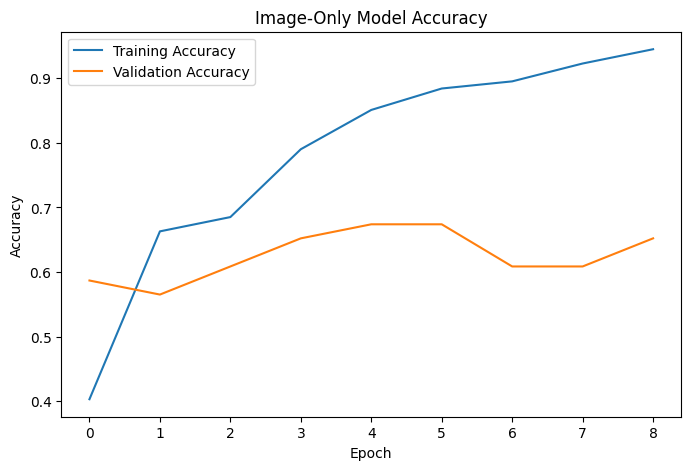

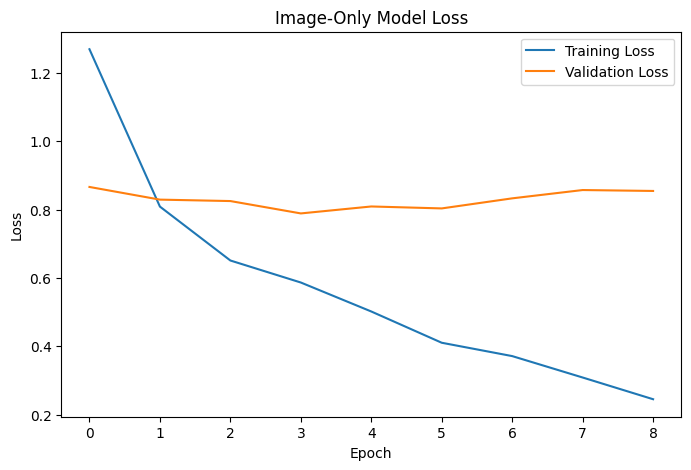

In [ ]:
# ============================================
# Stage 8: Plot Training History
# ============================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Image-Only Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Image-Only Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step
Image-Only Model Accuracy: 0.6316
Image-Only Model Weighted F1: 0.6265

Classification Report:
              precision    recall  f1-score   support

        high       0.59      0.68      0.63        19
         low       0.67      0.74      0.70        19
      medium       0.64      0.47      0.55        19

    accuracy                           0.63        57
   macro avg       0.63      0.63      0.63        57
weighted avg       0.63      0.63      0.63        57



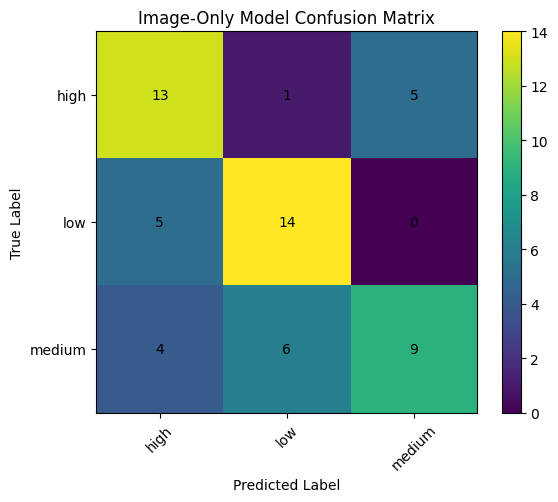

In [ ]:
# ============================================
# Stage 8: Evaluate Image-Only Model
# ============================================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

y_pred_probs = image_model.predict(X_test_preprocessed)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true, y_pred)
weighted_f1 = f1_score(y_true, y_pred, average="weighted")

print("Image-Only Model Accuracy:", round(accuracy, 4))
print("Image-Only Model Weighted F1:", round(weighted_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Image-Only Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    ticks=np.arange(len(label_encoder.classes_)),
    labels=label_encoder.classes_,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(label_encoder.classes_)),
    labels=label_encoder.classes_
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()